In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [2]:
api = wandb.Api()

In [3]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s14/distill-layerwise/run4-sanity-check-pca-and-prca-inv"

In [21]:
def read_data(
    teacher,
    arr_students,
    policy,
    dataset,
    lambda_task,
    lambda_kd,
    lambda_layer,
    training_size,
    contamination_level,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": {"$in": arr_students}},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": lambda_layer},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": contamination_level},
            {"config.dataset":  dataset},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics" in run.summary:
            count += 1
            print("> ", run.config["dataset"])
            continue
         
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        compression_rate = int(run.config["student"].split("compr")[1])
        
        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                student=run.config["student"],
                compression_rate=compression_rate,
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["policy_lambda_layer"],
                training_size=run.config["training_size"],
                contamination_level=run.config["contamination_level"],

                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
            )
        )

    if count > 0:
        print(f"We have {count} failed runs!")
    
    df = pd.DataFrame(rows)

      
    df = df.groupby(by=["compression_rate"]).agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_acc"]["count"].values,
        5,
        err_msg="number of count should eqalt to the number of CIFAR100 superclasses"
    )

    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-v1",
    arr_students=[
        "resnet18cifarcompr2",
#         "resnet18cifarcompr4",
#         "resnet18cifarcompr8",
#         "resnet18cifarcompr16",
        "resnet18cifarcompr32",
    ],
    policy="basis-identity:pca--uncentered",
    dataset="cifar100-people",
    training_size=1.0,
    contamination_level=0.0,
    lambda_task=0.0,
    lambda_kd=1.0,
    lambda_layer=1e4,
    verbose=True,
)

summary

we have 10 runs
df.shape: (2, 11)


compression_rate val_acc                 val_agreement                  \
                      mean       std count          mean       std count   
0                2  0.6216  0.009317     5        0.6688  0.020425     5   
1               32  0.5684  0.015060     5        0.5716  0.015900     5   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                           0.4972  0.011367     5        0.62  
1                           0.4424  0.008877     5        0.62

# Comparison on `training-size` and `contamination-level`

we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)


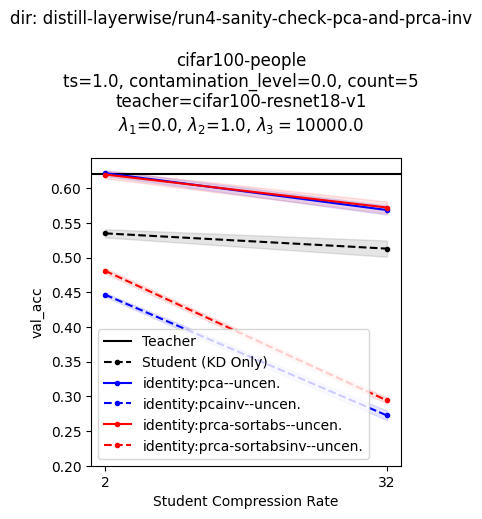

In [25]:
def ls(policy):
    if policy in ["fitnet", "attention-transfer", "vid"] :
        return ":"
    elif policy == "nothing":
        return "--"
    elif "inv" in policy:
        return "--"
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(policy):
    
    if policy == "nothing":
        return "Student (KD Only)"
    
    return policy \
        .replace("basis-identity", "identity") \
        .replace("uncentered", "uncen.")

    
    
def color(policy):
    if "pca" in policy:
        return "blue"
    elif "prca" in policy:
        return "red"
    elif "random" in policy:
        return "gray"
    elif "nothing" == policy:
        return "black"
    elif "inv" in policy:
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz_distillation(
    teacher,
    dataset,
    policies, 
    contamination_level,
    show_legend=True,
    include_baseline=True,
):
    
    training_size = 1.0
        
    arr_students = [
        "resnet18cifarcompr2",
#         "resnet18cifarcompr4",
#         "resnet18cifarcompr8",
#         "resnet18cifarcompr16",
        "resnet18cifarcompr32",
    ]
        
    lambda_kd = 1.0
    lambda_task = 0.0
    lambda_layer = 1e4
    
        

    col = "val_acc"
    
    ncols = 1
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])
    
    for pix, policy in enumerate(policies):

        
        df = read_data(
            teacher=teacher,
            arr_students=arr_students,
            policy=policy,
            dataset=dataset,
            lambda_layer=lambda_layer,
            lambda_task=lambda_task,
            lambda_kd=lambda_kd,
            contamination_level=contamination_level,
            training_size=training_size,
            verbose=True
        )
        

        ticks = df["compression_rate"]
        

            
        # visualize baseline
        if pix == 0:

            plt.axhline(
                df["teacher_acc"].values[-1],
                ls="-",
                color="k",
                label="Teacher"
            )

        # here, we take the first value.
        # the query function already checks that the value is expected
        count = df[col]["count"].values[-1]

        mean = df[col]["mean"]
        stderr = df[col]["std"] / (count ** 0.5)

        plt.plot(
            ticks,
            mean,
            marker=".",
            label=alias(policy),
            ls=ls(policy),
            color=color(policy)
        )

        plt.fill_between(
            ticks,
            mean - stderr,
            mean + stderr,
            alpha=0.1,
            color=plt.gca().lines[-1].get_color()
        )

    plt.xlabel("Student Compression Rate")
    plt.xticks(ticks)
    plt.ylabel(col)
    plt.ylim(bottom=0.2)

    plt.legend()

    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            dataset,
            f"ts={training_size}, contamination_level={contamination_level}, count={count}",
            f"teacher={teacher}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}, $\lambda_3={lambda_layer}$",
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    dataset = "cifar100-people",
    contamination_level=0.0,
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:pcainv--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:prca-sortabsinv--uncentered",
    ],
    include_baseline=False
) 

we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)
we have 10 runs
df.shape: (2, 11)


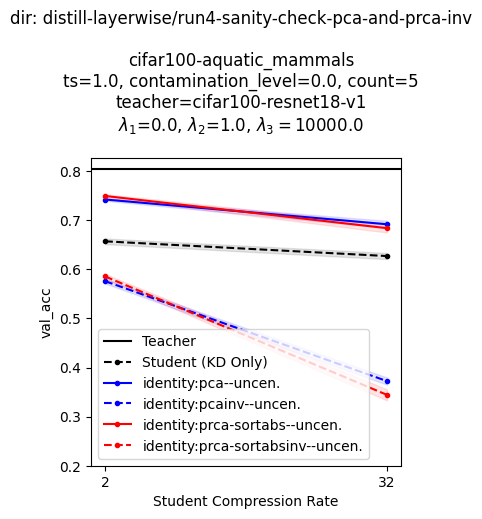

In [26]:

viz_distillation(
    teacher = "cifar100-resnet18-v1",
    dataset = "cifar100-aquatic_mammals",
    contamination_level=0.0,
    policies = [ 
        "nothing",
        "basis-identity:pca--uncentered",
        "basis-identity:pcainv--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        "basis-identity:prca-sortabsinv--uncentered",
    ],
    include_baseline=False
) 

# Summary

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3$ is set to $10^4$.

|Role| Name | $d_1$ | $d_2$ | $d_3$ | $d_4$  |
|:---:|------:|:-:|:-:|:-:|:-:|
|Teacher| `cifar100-resnet18-v1`  | 64 | 128 |256 | 512 |
|Student| `resnet18cifarcompr2` | 32 | 64 | 128 | 256 |
|Student| `resnet18cifarcompr32` | 32 | 64 | 8 | 16 |


## Aims: 
- sanity-check that using `pca` and `prca` in reverse order should lead to bad student model. We would expect also that the gap between `prca` and its inverse should be larger than the `pca` pair.


## Conclusion:
- We seed that indeed using the `pca` and `prca` bases leads to poor performance. 
- But, the gap between the `prca` pair is actually *smaller* than the `pca` pair. This suggests the ortho complement subspace of `prca` contains more information than the one of `pca`.  